# Figure 1 and S1 Bleo/Blast and puro selection

Notes:

1. Singlets
2. Infected EF1a-Nb(EGFP)-anti-TagBFP-P2A-iRFP670-WPRE


Selection protocol:
1. Infect in suspension with MOI 5 at 20k/96-well
2. After at least 2 dpi, reseed at 20k/96-well into antibiotic
3. Refresh antibiotic after 2 days with treatment, 4 dpt, then flow on 6 dpt. Kept blast and bleo going until 10 dpt.

In [1]:
import pandas as pd
import numpy as np
import re
from matplotlib import pyplot as plt
from matplotlib import ticker as mticker
from matplotlib.ticker import ScalarFormatter
from pathlib import Path
import seaborn as sns
from statannotations.Annotator import Annotator
import rushd as rd
import matplotlib
from scipy.optimize import curve_fit
from scipy.stats import poisson
from scipy.optimize import fsolve
from matplotlib.patches import Patch

**Global parameters**

In [2]:
alpha_tech_rep = 0.45
alpha_mean = 0.75
markersize = 7

In [18]:
# Convert p-value to significance stars
def p_to_stars(p):
    if p < 0.0001:
        return '****'
    elif p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'


# Function for drawing brackets
def add_sig_bracket(ax, x1, x2, y, h, p):
    
    ax.plot(
        [x1, x1, x2, x2],
        [y, y+h, y+h, y],
        color='black',
        linewidth=1,
        clip_on=False
    )
    
    ax.text(
        (x1 + x2) / 2,
        y + h,
        p_to_stars(p),
        ha='center',
        va='bottom',
        fontsize=9
    )

# Load data

Directories for all

In [3]:
# Directories 
output_path_supplement = rd.rootdir/'output'/'Figure_S1'
output_path = rd.rootdir/'output'/'Figure_1'
cache_path = rd.rootdir/'output'/'Figure_S1_blast_bleo'/'data.gzip'


**Load in puro data for new experiment**

In [42]:
# Data path
datadir = rd.datadir /'data'/ 'attune'/ "Mary" / "2026.06.03_exp47" # Data path
puro_cache_path = rd.rootdir/'output'/'Figure_S1_blast_bleo'/'data.gzip'

if puro_cache_path.exists():
    df_puro = pd.read_parquet(puro_cache_path)

else: 
    
    # Load plate 1 
    path_1 = datadir / 'Plate1'
    df_puro_1 = rd.flow.load_csv_with_metadata(path_1/'export_singlets', path_1/'export_singlets'/'well_metadata.yaml')

    # Load plate 2
    path_2 = datadir / 'Plate2'
    df_puro_2 = rd.flow.load_csv_with_metadata(path_2/'export_singlets', path_2/'export_singlets'/'well_metadata.yaml')

    # Load plate 3
    path_3 = datadir / 'Plate3'
    df_puro_3 = rd.flow.load_csv_with_metadata(path_3/'export_singlets', path_3/'export_singlets'/'well_metadata.yaml')

    # Convert list of dfs into single df
    df_puro = pd.concat([df_puro_1, df_puro_2, df_puro_3], ignore_index=True)

    # Shorten df
    channel_list = ['reporter', 'Date', 'well', 'Puro#', 'mGL-A', 'mGL-H', 'iRFP670-A','iRFP670-H', 'mRuby2-A', 'mRuby2-H', 'TagBFP-A', 'TagBFP-H',]
    df_puro = df_puro.loc[:, channel_list]

    # channel_sub_list = ['mGL-A', 'mGL-H', 'iRFP670-A','iRFP670-H', 'mRuby2-A', 'mRuby2-H', 'TagBFP-A', 'TagBFP-H']
    # for c in channel_sub_list: df_puro = df_puro[df_puro[c] > 0]

    # Add blast and zeo is 0
    df_puro.loc[:, 'blast'] = 0
    df_puro.loc[:, 'zeo'] = 0
    df_puro.loc[:, 'dpt'] = 6
    df_puro.loc[:,'experiment'] = 'select'

    # Save shortened df
    df_puro.to_parquet(rd.outfile(puro_cache_path))

In [43]:
display(df_puro)

,reporter,Date,well,Puro#,mGL-A,mGL-H,iRFP670-A,iRFP670-H,mRuby2-A,mRuby2-H,TagBFP-A,TagBFP-H,blast,zeo,dpt,experiment
0,pKG05002,2026.06.03.x,A10,10.0,114.0,89.0,20199.0,17256.0,90.0,186.0,51.0,84.0,0,0,6,select
1,pKG05002,2026.06.03.x,A10,10.0,-78.0,80.0,17792.0,13077.0,-66.0,70.0,-14.0,58.0,0,0,6,select
2,pKG05002,2026.06.03.x,A10,10.0,66680.0,48986.0,46504.0,37146.0,23058.0,17791.0,570.0,381.0,0,0,6,select
3,pKG05002,2026.06.03.x,A10,10.0,67.0,50.0,10007.0,8310.0,167.0,204.0,255.0,141.0,0,0,6,select
4,pKG05002,2026.06.03.x,A10,10.0,78.0,63.0,17562.0,14627.0,225.0,235.0,155.0,151.0,0,0,6,select
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22799791,pKG05003,2026.06.03.xxx,H9,5.0,-97.0,68.0,1690.0,1399.0,564.0,349.0,181.0,159.0,0,0,6,select
22799792,pKG05003,2026.06.03.xxx,H9,5.0,48.0,136.0,8106.0,6089.0,10220.0,6907.0,215.0,171.0,0,0,6,select
22799793,pKG05003,2026.06.03.xxx,H9,5.0,-30.0,59.0,15980.0,12856.0,2477.0,1941.0,252.0,162.0,0,0,6,select
22799794,pKG05003,2026.06.03.xxx,H9,5.0,172.0,92.0,18389.0,14684.0,6337.0,4767.0,252.0,160.0,0,0,6,select


**Rename mGL-A and mGL-H columns to eGFP-A and eGFP-H**

In [44]:
df_puro = df_puro.rename(columns={'mGL-A': 'eGFP-A', 'mGL-H': 'eGFP-H', 'Date':'rep', 'Puro#':'puro','reporter':'cond'})
df_puro.loc[df_puro['rep'] == '2026.06.03.x', 'rep'] = 1
df_puro.loc[df_puro['rep'] == '2026.06.03.xx', 'rep'] = 2
df_puro.loc[df_puro['rep'] == '2026.06.03.xxx', 'rep'] = 3

In [45]:
display(df_puro)

,cond,rep,well,puro,eGFP-A,eGFP-H,iRFP670-A,iRFP670-H,mRuby2-A,mRuby2-H,TagBFP-A,TagBFP-H,blast,zeo,dpt,experiment
0,pKG05002,1,A10,10.0,114.0,89.0,20199.0,17256.0,90.0,186.0,51.0,84.0,0,0,6,select
1,pKG05002,1,A10,10.0,-78.0,80.0,17792.0,13077.0,-66.0,70.0,-14.0,58.0,0,0,6,select
2,pKG05002,1,A10,10.0,66680.0,48986.0,46504.0,37146.0,23058.0,17791.0,570.0,381.0,0,0,6,select
3,pKG05002,1,A10,10.0,67.0,50.0,10007.0,8310.0,167.0,204.0,255.0,141.0,0,0,6,select
4,pKG05002,1,A10,10.0,78.0,63.0,17562.0,14627.0,225.0,235.0,155.0,151.0,0,0,6,select
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22799791,pKG05003,3,H9,5.0,-97.0,68.0,1690.0,1399.0,564.0,349.0,181.0,159.0,0,0,6,select
22799792,pKG05003,3,H9,5.0,48.0,136.0,8106.0,6089.0,10220.0,6907.0,215.0,171.0,0,0,6,select
22799793,pKG05003,3,H9,5.0,-30.0,59.0,15980.0,12856.0,2477.0,1941.0,252.0,162.0,0,0,6,select
22799794,pKG05003,3,H9,5.0,172.0,92.0,18389.0,14684.0,6337.0,4767.0,252.0,160.0,0,0,6,select


Load in blast and bleo data

In [46]:
# Data path
datadir = rd.datadir /'data'/ 'attune'/ "nat_attune" / "desNb-circuits" # Fig path
blastbleo_path = datadir / '2025.12.15_vDN194-195-select' / '2025.12.15_vDN194-195-select_6dpt'
blastlet_cache_path = rd.rootdir/'output'/'Figure_S1_blast_bleo'/'data_bleo1.gzip'


if blastlet_cache_path.exists():
    df_blastbleo = pd.read_parquet(blastlet_cache_path)

else: 
    df_blastbleo = rd.flow.load_csv_with_metadata(blastbleo_path/'export_singlets', blastbleo_path/'metadata.yaml')

    # Shorten df
    channel_list = ['experiment', 'dpt', 'cond', 'rep', 'well', 'blast', 'zeo', 'eGFP-A', 'eGFP-H', 'iRFP670-A','iRFP670-H', 'mRuby2-A', 'mRuby2-H', 'TagBFP-A', 'TagBFP-H',]
    df_blastbleo = df_blastbleo.loc[:, channel_list]

    # Add puro is 0
    df_blastbleo.loc[:, 'puro'] = 0

    # Save shortened df
    df_blastbleo.to_parquet(rd.outfile(blastlet_cache_path))

In [47]:
# Data path
datadir = rd.datadir /'data'/ 'attune'/ "nat_attune" / "desNb-circuits" # Fig path
blastbleo_path_2 = datadir/ '2025.12.15_vDN194-195-select' / '2025.12.19_vDN194-195-select'
blastlet_cache_path_2 = rd.rootdir/'output'/'Figure_S1_blast_bleo'/'data_bleo2.gzip'


df_blastbleo_2 = pd.DataFrame()
if blastlet_cache_path_2.exists():
    df_blastbleo_2 = pd.read_parquet(blastlet_cache_path_2)

else: 
    df_blastbleo_2 = rd.flow.load_csv_with_metadata(blastbleo_path_2/'export_singlets', blastbleo_path_2/'metadata.yaml')


    # Shorten df
    channel_list = ['experiment', 'dpt', 'cond', 'rep', 'well', 'blast', 'zeo', 'eGFP-A', 'eGFP-H', 'iRFP670-A','iRFP670-H', 'mRuby2-A', 'mRuby2-H', 'TagBFP-A', 'TagBFP-H',]
    df_blastbleo_2 = df_blastbleo_2.loc[:, channel_list]

    # Add puro is 0
    df_blastbleo_2.loc[:, 'puro'] = 0

    # Save shortened df
    df_blastbleo_2.to_parquet(rd.outfile(blastlet_cache_path_2))

In [48]:
display(df_blastbleo_2)

,experiment,dpt,cond,rep,well,blast,zeo,eGFP-A,eGFP-H,iRFP670-A,iRFP670-H,mRuby2-A,mRuby2-H,TagBFP-A,TagBFP-H,puro
0,select,10,vDN195,1,A1,0,0,-101,3,11573,7930,242,268,2970.0,1965,0
1,select,10,vDN195,1,A1,0,0,69,61,5665,3777,194,192,1982.0,1331,0
2,select,10,vDN195,1,A1,0,0,152,99,15366,10942,395,221,1512.0,1209,0
3,select,10,vDN195,1,A1,0,0,-39,20,6209,4766,254,217,936.0,771,0
4,select,10,vDN195,1,A1,0,0,126,96,2061,1478,379,268,1345.0,1034,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512346,select,10,Ctrl-neg,3,C8,0,0,63,115,92,67,201,107,141.0,132,0
512347,select,10,Ctrl-neg,3,C8,0,0,235,90,285,105,1081,804,1483.0,807,0
512348,select,10,Ctrl-neg,3,C8,0,0,94,136,113,113,718,629,964.0,763,0
512349,select,10,Ctrl-neg,3,C8,0,0,99,79,233,113,648,417,484.0,478,0


Combine df

In [49]:
df_all = pd.concat([df_puro, df_blastbleo, df_blastbleo_2], ignore_index=True)

In [50]:
display(df_all)

,cond,rep,well,puro,eGFP-A,eGFP-H,iRFP670-A,iRFP670-H,mRuby2-A,mRuby2-H,TagBFP-A,TagBFP-H,blast,zeo,dpt,experiment
0,pKG05002,1,A10,10.0,114.0,89.0,20199.0,17256.0,90.0,186.0,51.0,84.0,0,0,6,select
1,pKG05002,1,A10,10.0,-78.0,80.0,17792.0,13077.0,-66.0,70.0,-14.0,58.0,0,0,6,select
2,pKG05002,1,A10,10.0,66680.0,48986.0,46504.0,37146.0,23058.0,17791.0,570.0,381.0,0,0,6,select
3,pKG05002,1,A10,10.0,67.0,50.0,10007.0,8310.0,167.0,204.0,255.0,141.0,0,0,6,select
4,pKG05002,1,A10,10.0,78.0,63.0,17562.0,14627.0,225.0,235.0,155.0,151.0,0,0,6,select
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23658188,Ctrl-neg,3,C8,0.0,63.0,115.0,92.0,67.0,201.0,107.0,141.0,132.0,0,0,10,select
23658189,Ctrl-neg,3,C8,0.0,235.0,90.0,285.0,105.0,1081.0,804.0,1483.0,807.0,0,0,10,select
23658190,Ctrl-neg,3,C8,0.0,94.0,136.0,113.0,113.0,718.0,629.0,964.0,763.0,0,0,10,select
23658191,Ctrl-neg,3,C8,0.0,99.0,79.0,233.0,113.0,648.0,417.0,484.0,478.0,0,0,10,select


# Gating for integrated cells

## Gate infection marker

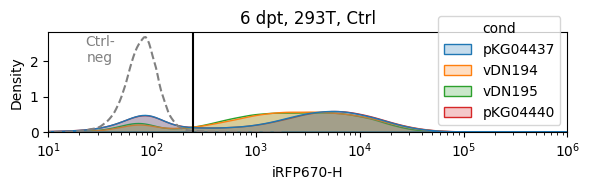

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(6, 2))

# Threshold for iRFP670
iRFP670_H_thresh = 2.5e2

# Plot iRFP670-H
x = 'iRFP670-H'
hue = 'cond'
hue_order = ['pKG04437', 'vDN194', 'vDN195', 'pKG04440']


sns.kdeplot(data=df_all.loc[(df_all.puro == 0) & (df_all.zeo == 0) & (df_all.blast == 0) & (df_all[x] > 0) & (df_all.cond != 'Ctrl-neg') ],
        ax=ax, x=x, hue=hue,
        hue_order=hue_order,
        common_norm=False, log_scale=(True, False),
        fill=True)

# Plot neg ctrl
sns.kdeplot(
    data=df_all.loc[(df_all.cond=='Ctrl-neg')& (df_all[x] > 0)],
    ax=ax, x=x,
    common_norm=False, log_scale=(True, False),
    fill=False, linestyle='--', color='grey', legend=False)
ax.annotate('Ctrl-\nneg', (0.1, 0.7), color='grey', xycoords='axes fraction', ha='center')

# Plot threshold
ax.axvline(iRFP670_H_thresh, 0, 1, color='black')


# Title
plt.title('6 dpt, 293T, Ctrl')
# Adjust limits
mRuby2_lim = (10, 1*10**6)
for sub_ax in plt.gcf().get_axes():
    sub_ax.set_xlim(mRuby2_lim)

# Misc plotting stuff
fig.tight_layout()  # Helps improve white spacing

In [51]:
# Categorize cells based on iRFP670_thresh
df_all.loc[:, 'iRFP670_cat'] = 'iRFP670-'
df_all.loc[(df_all['iRFP670-H'] > iRFP670_H_thresh), 'iRFP670_cat'] = 'iRFP670+'

# Get total counts and percent of GFP-H+
group = [ 'experiment', 'cond', 'rep', 'dpt', 'blast', 'zeo', 'puro']
count_df_reps = df_all.groupby([*group, 'well', 'iRFP670_cat'])[
    'iRFP670-H'].count().unstack(fill_value=0).stack().rename('count') # Puts 0 if no GFP-H+ rather than dropping row
percent_df_reps = (count_df_reps*100/count_df_reps.groupby([*group, 'well']).transform('sum')).reset_index(name='percent')
data_iRFP670_count_reps = count_df_reps.reset_index()

# Extract just the iRFP670+
data_iRFP670_percent_reps = percent_df_reps.loc[(percent_df_reps['iRFP670_cat'] == 'iRFP670+')]
data_iRFP670_count_reps = data_iRFP670_count_reps.loc[(data_iRFP670_count_reps['iRFP670_cat'] == 'iRFP670+')]

## EGFP purity

**Figure S1A - eGFP Distribution**

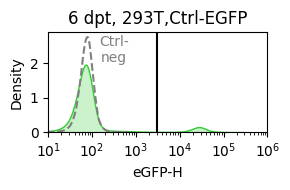

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2))

# Threshold for GFP
eGFP_H_thresh = 3*10**3

# Plot eGFP-H
x = 'eGFP-H'

# Plot Ctrl-EGFP
cond = 'Ctrl-EGFP'
sns.kdeplot(data=df_all.loc[(df_all['cond'] == cond) & (df_all[x] > 0)],
        ax=ax, x=x,
        common_norm=False, log_scale=(True, False), color='limegreen',
        fill=True)

# Plot neg ctrl
sns.kdeplot(
    data=df_all.loc[(df_all.cond=='Ctrl-neg')& (df_all[x] > 0)],
    ax=ax, x=x,
    common_norm=False, log_scale=(True, False),
    fill=False, linestyle='--', color='grey', legend=False)
ax.annotate('Ctrl-\nneg', (0.3, 0.7), color='grey', xycoords='axes fraction', ha='center')


# Plot threshold
ax.axvline(eGFP_H_thresh, 0, 1, color='black')

# Title
plt.title(f'6 dpt, 293T,{cond}')
# Adjust limits
eGFP_lim = (10, 1*10**6)
for sub_ax in plt.gcf().get_axes():
    sub_ax.set_xlim(eGFP_lim)

# Misc plotting stuff
fig.tight_layout()  # Helps improve white spacing

plottitle = 'Figure_S1A_eGFP.svg'
plt.savefig(rd.outfile(output_path_supplement/plottitle),bbox_inches='tight')

In [52]:
# Categorize cells based on eGFP_thresh
df_all.loc[:, 'eGFP_cat'] = 'eGFP-'
df_all.loc[(df_all['eGFP-H'] > eGFP_H_thresh), 'eGFP_cat'] = 'eGFP+'

# Gate infected cells
df_infected = df_all.loc[(df_all['iRFP670_cat'] == 'iRFP670+')].copy()

# Get total counts and percent of GFP-H+ of the infected cells
group = [ 'experiment', 'cond', 'rep', 'dpt', 'blast', 'zeo', 'puro']
count_df_reps = df_infected.groupby([*group, 'well', 'eGFP_cat'])[
    'eGFP-H'].count().unstack(fill_value=0).stack().rename('count').copy() # Puts 0 if no GFP-H+ rather than dropping row
percent_df_reps = (count_df_reps*100/count_df_reps.groupby([*group, 'well']).transform('sum')).reset_index(name='percent')
data_eGFP_count_reps = count_df_reps.reset_index()

# Extract just the eGFP+
data_eGFP_percent_reps = percent_df_reps.loc[(percent_df_reps['eGFP_cat'] == 'eGFP+')]
data_eGFP_count_reps = data_eGFP_count_reps.loc[(data_eGFP_count_reps['eGFP_cat'] == 'eGFP+')]

In [17]:
sns.set_context('paper')

### Plot just wtNb vs. desNb

**Figure 1D Puro selection**

0.02804742511159857
Significance: ns = p >= 0.05, * = p < 0.05, ** = p < 0.01, *** = p < 0.001, **** = p < 0.0001
wtNb: 40 µg/mL vs 0 µg/mL p = 0.02804742511159857
desNb: 40 µg/mL vs 0 µg/mL p = 4.687894286057846e-07


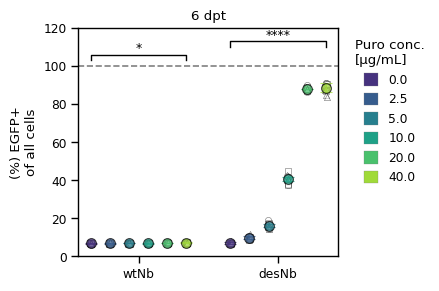

In [62]:
# General plotting params
x = 'cond'
y = 'percent'
marker_list = ['o', 's', '^', 'D', 'P', 'X']

order = ['pKG04437', 'pKG04440']
label_map = {'pKG04437':'wtNb', 'pKG04440':'desNb'}

df_curr = data_eGFP_percent_reps.loc[
    (data_eGFP_percent_reps.cond == 'pKG04437') |
    (data_eGFP_percent_reps.cond == 'pKG04440')
]
df_curr = df_curr.loc[df_curr.dpt == 6]

hue = 'puro'
hue_order = np.sort(df_curr[hue].unique())

# Calculate biological replicate means


bio_means = (
    df_curr
    .groupby(['cond', 'puro', 'rep'], as_index=False)['percent']
    .mean()
)

summary = (
    bio_means
    .groupby(['cond', 'puro'], as_index=False)
    .agg(
        mean=('percent', 'mean'),
        sd=('percent', 'std'),
        sem=('percent', lambda x: x.std(ddof=1)/np.sqrt(len(x)))
    )
)


fig, ax = plt.subplots(1, 1, figsize=(4.5,3))

colors = sns.color_palette("viridis", len(hue_order))

# Horizontal offsets for each puro concentration
offsets = np.linspace(-0.12, 0.12, len(hue_order))
group_centers = [0, 0.35]
# Tiny offsets for technical replicates
rep_offsets = np.linspace(-0.02, 0.02, len(bio_means.rep.unique()))

# ---------------------------------------------------------
# Plot technical replicates
# ---------------------------------------------------------

# Get unique biological replicates
rep_order = sorted(df_curr['rep'].unique())

for rep_idx, rep in enumerate(rep_order):

    rep_data = df_curr[df_curr['rep'] == rep]

    for i, cond in enumerate(order):
        for j, puro in enumerate(hue_order):

            # Get all technical replicates for this biological replicate
            row = rep_data[
                (rep_data['cond'] == cond) &
                (rep_data['puro'] == puro)
            ]

            if row.empty:
                continue

            xloc = group_centers[i] + offsets[j]

            # Slight horizontal jitter so technical reps are visible
            tech_x = (
                xloc
                + np.linspace(
                    -0.0015,
                    0.0015,
                    len(row)
                )
            )

            ax.scatter(
                tech_x,
                row['percent'],
                marker=marker_list[rep_idx],
                s=20,
                facecolors='white',
                edgecolors='black',
                linewidth=0.5,
                alpha=alpha_tech_rep,
                zorder=2
            )

# Plot biological replicate mean ± SD


for i, cond in enumerate(order):
    for j, puro in enumerate(hue_order):

        row = summary[
            (summary.cond == cond) &
            (summary.puro == puro)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[j]

        ax.errorbar(
            xloc,
            row['mean'].iloc[0],
            yerr=row['sd'].iloc[0],   # change to row['sem'] if desired
            fmt='o',
            markersize=markersize,
            color=colors[j],
            alpha=alpha_mean,
            mec='black',
            mew=0.8,
            capsize=4,
            lw=1.3,
            zorder=5
        )


ax.yaxis.set_label_text('(%) EGFP+\nof all cells')
ax.set_ylim((0,115))


legend_handles = [
    Patch(facecolor=color, edgecolor='grey',
          label=str(puro), linewidth=0.2)
    for color, puro in zip(colors, hue_order)
]

ax.legend(
    handles=legend_handles,
    title='Puro conc.\n[µg/mL]',
    loc='upper left',
    bbox_to_anchor=(1.02,1),
    frameon=False,
    handlelength=1.2,
    handleheight=1.2
)

ax.set_title('6 dpt')
ax.axhline(100, color='grey', linestyle='--')

ax.set_xlabel('')
ax.set_xticks(group_centers)
ax.set_xticklabels([label_map[l] for l in order])

# ---------------------------------------------------------
# Add statistical significance brackets
# ---------------------------------------------------------

from scipy.stats import ttest_ind

# Get x positions for the relevant conditions
wtNb_40_x = group_centers[0] + offsets[list(hue_order).index(40)]
desNb_0_x = group_centers[1] + offsets[list(hue_order).index(0)]
desNb_40_x = group_centers[1] + offsets[list(hue_order).index(40)]
wtNb_0_x = group_centers[0] + offsets[list(hue_order).index(0)]

# Get biological replicate data
wtNb_40 = bio_means[
    (bio_means['cond'] == 'pKG04437') &
    (bio_means['puro'] == 40)
]['percent']

wtNb_0 = bio_means[
    (bio_means['cond'] == 'pKG04437') &
    (bio_means['puro'] == 0)
]['percent']

desNb_40 = bio_means[
    (bio_means['cond'] == 'pKG04440') &
    (bio_means['puro'] == 40)
]['percent']

desNb_0 = bio_means[
    (bio_means['cond'] == 'pKG04440') &
    (bio_means['puro'] == 0)
]['percent']


# Student's two-sided independent t-tests
_, p_wt_vs_des_40 = ttest_ind(
    wtNb_40,
    desNb_40,
    equal_var=True,
    alternative='two-sided'
)

_, p_des_0_vs_40 = ttest_ind(
    desNb_0,
    desNb_40,
    equal_var=True,
    alternative='two-sided'
)

_, p_wt_0_vs_40 = ttest_ind(
    wtNb_0,
    wtNb_40,
    equal_var=True,
    alternative='two-sided'
)



# ---------------------------------------------------------
# Add brackets to graph
# ---------------------------------------------------------

# wtNb 40 µg/mL vs desNb 40 µg/mL
add_sig_bracket(
    ax,
    wtNb_0_x,
    wtNb_40_x,
    y=103,
    h=3,
    p=p_wt_0_vs_40
)


# desNb 0 µg/mL vs desNb 40 µg/mL
add_sig_bracket(
    ax,
    desNb_0_x,
    desNb_40_x,
    y=110,
    h=3,
    p=p_des_0_vs_40
)


# Increase ylim to make room for brackets
ax.set_ylim(0, 120)
fig.tight_layout()

plottitle = 'Figure_1D_purity_dots_tall.svg'
plt.savefig(rd.outfile(output_path/plottitle), bbox_inches='tight')
print(p_wt_0_vs_40)
print(
    "Significance: "
    "ns = p >= 0.05, "
    "* = p < 0.05, "
    "** = p < 0.01, "
    "*** = p < 0.001, "
    "**** = p < 0.0001"
)
# Mean biological replicate count at 0 and 10 µg/mL
wtNb_0_mean = bio_means.loc[
    (bio_means['cond'] == 'pKG04437') &
    (bio_means['puro'] == 0),
    'percent'
].mean()

wtNb_40_mean = bio_means.loc[
    (bio_means['cond'] == 'pKG04437') &
    (bio_means['puro'] == 40),
    'percent'
].mean()

desNb_0_mean = bio_means.loc[
    (bio_means['cond'] == 'pKG04440') &
    (bio_means['puro'] == 0),
    'percent'
].mean()

desNb_40_mean = bio_means.loc[
    (bio_means['cond'] == 'pKG04440') &
    (bio_means['puro'] == 40),
    'percent'
].mean()


# Calculate fold changes
wtNb_fold_change = wtNb_40_mean / wtNb_0_mean
desNb_fold_change = desNb_40_mean / desNb_0_mean
# Print results
print(
    f"wtNb: 40 µg/mL vs 0 µg/mL p = "
    f"{p_wt_0_vs_40}"
)

print(
    f"desNb: 40 µg/mL vs 0 µg/mL p = "
    f"{p_des_0_vs_40}"
)

**Figure S1B eGFP+ count**

wtNb: 40 µg/mL vs 0 µg/mL = 1.49x
desNb: 10 µg/mL vs 0 µg/mL = 5.35x


array([1, 2, 3], dtype=int64)

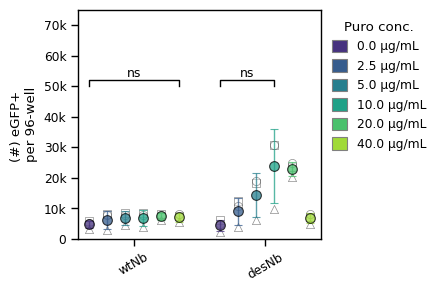

In [56]:
# General plotting params
x = 'cond'
y = 'count'

markers = {1:'s', 2:'o', 3:'^', 0:'D'}

order = ['pKG04437', 'pKG04440']
label_map = {'pKG04437':'wtNb', 'pKG04440':'desNb'}

df_curr = data_eGFP_count_reps.loc[(data_eGFP_count_reps.cond == 'pKG04437') & (data_eGFP_count_reps['eGFP_cat'] == 'eGFP+')| (data_eGFP_count_reps.cond == 'pKG04440')& (data_eGFP_count_reps['eGFP_cat'] == 'eGFP+')]
df_curr = df_curr.loc[df_curr.dpt == 6]

hue = 'puro'
hue_order = np.sort(df_curr[hue].unique())


palette = sns.color_palette("viridis", len(hue_order))

# Horizontal offsets for each puro concentration
offsets = np.linspace(-0.12, 0.12, len(hue_order))
group_centers = [0, 0.35]

# Tiny offsets for technical replicates
rep_offsets = np.linspace(-0.02, 0.02, len(bio_means.rep.unique()))

# Calculate mean of biological replicate means

bio_means = (
    df_curr
    .groupby(['cond', 'puro', 'rep'], as_index=False)[y]
    .mean()
)

summary = (
    bio_means
    .groupby(['cond', 'puro'], as_index=False)

    .agg(
        mean=(y, 'mean'),
        sd=(y, 'std')
    )
)
# ---------------------------------------------------------
# Calculate fold change: 10 µg/mL vs 0 µg/mL
# ---------------------------------------------------------

# Mean biological replicate count at 0 and 10 µg/mL
wtNb_0_mean = bio_means.loc[
    (bio_means['cond'] == 'pKG04437') &
    (bio_means['puro'] == 0),
    'count'
].mean()

wtNb_40_mean = bio_means.loc[
    (bio_means['cond'] == 'pKG04437') &
    (bio_means['puro'] == 40),
    'count'
].mean()

desNb_0_mean = bio_means.loc[
    (bio_means['cond'] == 'pKG04440') &
    (bio_means['puro'] == 0),
    'count'
].mean()

desNb_10_mean = bio_means.loc[
    (bio_means['cond'] == 'pKG04440') &
    (bio_means['puro'] == 10),
    'count'
].mean()


# Calculate fold changes
wtNb_fold_change = wtNb_40_mean / wtNb_0_mean
desNb_fold_change = desNb_10_mean / desNb_0_mean


# Print results
print(
    f"wtNb: 40 µg/mL vs 0 µg/mL = "
    f"{wtNb_fold_change:.2f}x"
)

print(
    f"desNb: 10 µg/mL vs 0 µg/mL = "
    f"{desNb_fold_change:.2f}x"
)

fig, ax = plt.subplots(1, 1, figsize=(4.5,3))

colors = dict(zip(hue_order, palette))

# positions
group_centers = [0, 0.35]
offsets = np.linspace(-0.12, 0.12, len(hue_order))

markers = {1:'s', 2:'o', 3:'^', 0:'D'}

# Technical replicate dots (back layer)

for rep, marker in markers.items():

    rep_data = bio_means[bio_means.rep == rep]

    for i, cond in enumerate(order):
        for j, puro in enumerate(hue_order):

            row = rep_data[
                (rep_data.cond == cond) &
                (rep_data.puro == puro)
            ]

            if row.empty:
                continue

            xloc = group_centers[i] + offsets[j]

            ax.scatter(
                xloc,
                row[y],
                marker=marker,
                s=35,
                facecolor='white',
                edgecolor='black',
                linewidth=0.5,
                alpha=alpha_tech_rep,
                zorder=2
            )

# Biological replicate mean dots (front layer)


for i, cond in enumerate(order):
    for j, puro in enumerate(hue_order):

        row = summary[
            (summary.cond == cond) &
            (summary.puro == puro)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[j]

        ax.errorbar(
            xloc,
            row['mean'].iloc[0],
            yerr=row['sd'].iloc[0],
            fmt='o',
            markersize=markersize,
            color=colors[puro],
            alpha=alpha_mean,
            mec='black',
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )

# Formatting

ax.yaxis.set_label_text('(#) eGFP+ \nper 96-well')
ax.xaxis.set_label_text('')
ax.set_ylim((0,75000))

ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(
        lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'
    )
)

ax.set_xticks(group_centers)

ax.set_xticklabels(
    [label_map[t] for t in order],
    rotation=30
)


# Legend
legend_handles = [
    Patch(
        facecolor=colors[p],
        edgecolor='grey',
        label=f'{p} µg/mL'
    )
    for p in hue_order
]

ax.legend(
    handles=legend_handles,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False,
    handlelength = 1.2,
    handleheight = 1.2
)

# Get x positions for the relevant conditions
wtNb_40_x = group_centers[0] + offsets[list(hue_order).index(40)]
desNb_0_x = group_centers[1] + offsets[list(hue_order).index(0)]
desNb_10_x = group_centers[1] + offsets[list(hue_order).index(10)]
wtNb_0_x = group_centers[0] + offsets[list(hue_order).index(0)]


# Get biological replicate data
wtNb_40 = bio_means[
    (bio_means['cond'] == 'pKG04437') &
    (bio_means['puro'] == 40)
]['count']

wtNb_0 = bio_means[
    (bio_means['cond'] == 'pKG04437') &
    (bio_means['puro'] == 0)
]['count']

desNb_10 = bio_means[
    (bio_means['cond'] == 'pKG04440') &
    (bio_means['puro'] == 10)
]['count']

desNb_0 = bio_means[
    (bio_means['cond'] == 'pKG04440') &
    (bio_means['puro'] == 0)
]['count']


# Student's two-sided independent t-tests
_, p_wt_vs_des_10 = ttest_ind(
    wtNb_40,
    desNb_10,
    equal_var=True,
    alternative='two-sided'
)

_, p_des_0_vs_10 = ttest_ind(
    desNb_0,
    desNb_10,
    equal_var=True,
    alternative='two-sided'
)

_, p_wt_0_vs_wt_40 = ttest_ind(
    wtNb_0,
    wtNb_40,
    equal_var=True,
    alternative='two-sided'
)


# desNb 0 µg/mL vs desNb 40 µg/mL
add_sig_bracket(
    ax,
    desNb_0_x,
    desNb_10_x,
    y=50000,
    h=2000,
    p=p_des_0_vs_10
)

add_sig_bracket(
    ax,
    wtNb_0_x,
    wtNb_40_x,
    y=50000,
    h=2000,
    p=p_wt_0_vs_wt_40
)

fig.tight_layout()

plottitle = 'Figure_S1B_eGFP_count_dots_tall.svg'
plt.savefig(rd.outfile(output_path_supplement/plottitle))

df_curr['rep'].unique()

**Figure S1B total transduced cell count**

wtNb: 40 µg/mL vs 0 µg/mL = 1.40x
desNb: 40 µg/mL vs 0 µg/mL = 0.12x


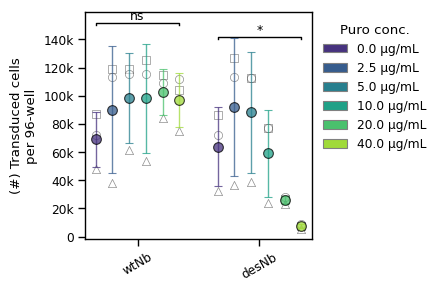

In [57]:
# General plotting params
x = 'cond'
y = 'count'
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

order = ['pKG04437', 'pKG04440']
label_map = {'pKG04437':'wtNb', 'pKG04440':'desNb'}

palette = sns.color_palette("viridis", len(hue_order))

df_curr = data_iRFP670_count_reps.loc[(data_iRFP670_count_reps.cond == 'pKG04437') | (data_iRFP670_count_reps.cond == 'pKG04440')]
df_curr = df_curr.loc[df_curr.dpt == 6]

hue = 'puro'
hue_order = np.sort(data_iRFP670_count_reps[hue].unique())
hue_order
# Calculate mean of biological replicate means

bio_means = (
    df_curr
    .groupby(['cond', 'puro', 'rep'], as_index=False)[y]
    .mean()
)

summary = (
    bio_means
    .groupby(['cond', 'puro'], as_index=False)
    .agg(
        mean=(y, 'mean'),
        sd=(y, 'std')
    )
)

fig, ax = plt.subplots(1, 1, figsize=(4.5,3))

colors = dict(zip(hue_order, palette))

# positions
group_centers = [0, 0.35]
offsets = np.linspace(-0.12, 0.12, len(hue_order))

markers = {1:'s', 2:'o', 3:'^', 0:'D'}

# Technical replicate dots (back layer)

for rep, marker in markers.items():

    rep_data = bio_means[bio_means.rep == rep]

    for i, cond in enumerate(order):
        for j, puro in enumerate(hue_order):

            row = rep_data[
                (rep_data.cond == cond) &
                (rep_data.puro == puro)
            ]

            if row.empty:
                continue

            xloc = group_centers[i] + offsets[j]

            ax.scatter(
                xloc,
                row[y],
                marker=marker,
                s=35,
                facecolor='white',
                edgecolor='black',
                linewidth=0.5,
                alpha=alpha_tech_rep,
                zorder=2
            )

# Biological replicate mean dots (front layer)


for i, cond in enumerate(order):
    for j, puro in enumerate(hue_order):

        row = summary[
            (summary.cond == cond) &
            (summary.puro == puro)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[j]

        ax.errorbar(
            xloc,
            row['mean'].iloc[0],
            yerr=row['sd'].iloc[0],
            fmt='o',
            markersize=markersize,
            color=colors[puro],
            alpha=alpha_mean,
            mec='black',
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )

# Formatting

ax.yaxis.set_label_text('(#) Transduced cells\nper 96-well')
ax.xaxis.set_label_text('')

ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(
        lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'
    )
)

ax.set_xticks(group_centers)

ax.set_xticklabels(
    [label_map[t] for t in order],
    rotation=30
)


# Legend
legend_handles = [
    Patch(
        facecolor=colors[p],
        edgecolor='grey',
        label=f'{p} µg/mL'
    )
    for p in hue_order
]

ax.legend(
    handles=legend_handles,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False
)

# Get x positions for the relevant conditions
wtNb_40_x = group_centers[0] + offsets[list(hue_order).index(40)]
desNb_0_x = group_centers[1] + offsets[list(hue_order).index(0)]
desNb_40_x = group_centers[1] + offsets[list(hue_order).index(40)]
wtNb_0_x = group_centers[0] + offsets[list(hue_order).index(0)]


# Get biological replicate data
wtNb_40 = bio_means[
    (bio_means['cond'] == 'pKG04437') &
    (bio_means['puro'] == 40)
]['count']

wtNb_0 = bio_means[
    (bio_means['cond'] == 'pKG04437') &
    (bio_means['puro'] == 0)
]['count']

desNb_40 = bio_means[
    (bio_means['cond'] == 'pKG04440') &
    (bio_means['puro'] == 40)
]['count']

desNb_0 = bio_means[
    (bio_means['cond'] == 'pKG04440') &
    (bio_means['puro'] == 0)
]['count']


# Student's two-sided independent t-tests
_, p_wt_vs_des_40 = ttest_ind(
    wtNb_40,
    desNb_40,
    equal_var=True,
    alternative='two-sided'
)

_, p_des_0_vs_40 = ttest_ind(
    desNb_0,
    desNb_40,
    equal_var=True,
    alternative='two-sided'
)

_, p_wt_0_vs_wt_40 = ttest_ind(
    wtNb_0,
    wtNb_40,
    equal_var=True,
    alternative='two-sided'
)


# desNb 0 µg/mL vs desNb 40 µg/mL
add_sig_bracket(
    ax,
    desNb_0_x,
    desNb_40_x,
    y=140000,
    h=2000,
    p=p_des_0_vs_40
)

add_sig_bracket(
    ax,
    wtNb_0_x,
    wtNb_40_x,
    y=150000,
    h=2000,
    p=p_wt_0_vs_wt_40
)
fig.tight_layout()


plottitle = 'Figure_S1B_total_count_dots.svg'
plt.savefig(rd.outfile(output_path_supplement/plottitle),bbox_inches='tight')

# Mean biological replicate count at 0 and 10 µg/mL
wtNb_0_mean = bio_means.loc[
    (bio_means['cond'] == 'pKG04437') &
    (bio_means['puro'] == 0),
    'count'
].mean()

wtNb_40_mean = bio_means.loc[
    (bio_means['cond'] == 'pKG04437') &
    (bio_means['puro'] == 40),
    'count'
].mean()

desNb_0_mean = bio_means.loc[
    (bio_means['cond'] == 'pKG04440') &
    (bio_means['puro'] == 0),
    'count'
].mean()

desNb_40_mean = bio_means.loc[
    (bio_means['cond'] == 'pKG04440') &
    (bio_means['puro'] == 40),
    'count'
].mean()


# Calculate fold changes
wtNb_fold_change = wtNb_40_mean / wtNb_0_mean
desNb_fold_change = desNb_40_mean / desNb_0_mean


# Print results
print(
    f"wtNb: 40 µg/mL vs 0 µg/mL = "
    f"{wtNb_fold_change:.2f}x"
)

print(
    f"desNb: 40 µg/mL vs 0 µg/mL = "
    f"{desNb_fold_change:.2f}x"
)


# Bleo and Blast Comparison at 6 vs 10 days

**Figure S1C bleo and blast comparison**

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_49988\1000207076.py:24: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.pointplot(
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_49988\1000207076.py:24: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.pointplot(


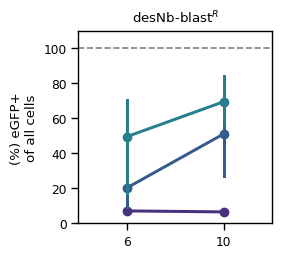

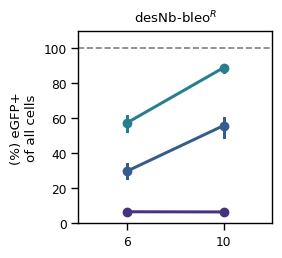

In [58]:
# General plotting params
x = 'dpt'
y = 'percent'

marker_list = ['o', 's', '^', 'D', 'P', 'X']   
palette = sns.color_palette("viridis", len(hue_order))
antibiotic_map = {'vDN193':'puro', 'vDN194':'blast', 'vDN195':'zeo', 'vDN196':'puro'}
label_map = {'vDN193':'wtNb-puro$^R$', 'vDN194':'desNb-blast$^R$', 'vDN195':'desNb-bleo$^R$', 'vDN196':'desNb-puro$^R$'}



for cond in ['vDN194', 'vDN195']:

    curr_df = data_eGFP_percent_reps.loc[(data_eGFP_percent_reps.cond == cond)]

    hue = antibiotic_map[cond]
    hue_order = np.sort(curr_df[hue].unique())


    # What to plot
    fig, ax = plt.subplots(1, 1, figsize=(2.5, 2.5))

    # Plot
    sns.pointplot(
        ax=ax, data=curr_df,
        x=x, y=y, hue=hue,
        palette=palette)

    # Formatting
    ax.yaxis.set_label_text('(%) eGFP+\nof all cells')
    ax.set_ylim((0, 110))
    
    # Remove existing legend
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    # Title
    ax.set_title(f'{label_map[cond]}')
    ax.axhline(100, 0, 1, color='grey', linestyle='--')
    ax.set_xlabel('')

    plottitle = 'Figure_S1C' + str(cond) + '.svg'
    plt.savefig(rd.outfile(output_path_supplement/plottitle),bbox_inches='tight')


**Figure 1E antibiotic comparison**

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_49988\2852163298.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_curr.loc[(df_curr['blast'] == 0) & (df_curr['cond'] == 'vDN194') & (df_curr['dpt'] == 10), 'anti_cat'] = '0'
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_49988\2852163298.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(label_map[l] for l in order)


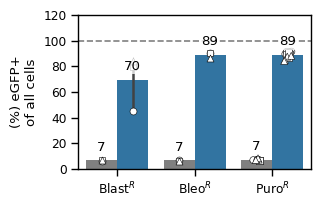

In [59]:
# General plotting params
x = 'cond'
y = 'percent'
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

order = ['vDN194', 'vDN195', 'pKG04440']

antibiotic_map = {'vDN194':'blast', 'vDN195':'zeo', 'pKG04440':'puro'}
label_map = {'vDN194':'Blast$^R$', 'vDN195':'Bleo$^R$', 'pKG04440':'Puro$^R$'}

# Just get desNb's ['vDN194', 'vDN195', 'vDN196']
df_curr = data_eGFP_percent_reps.loc[data_eGFP_percent_reps.cond.isin(order)]

# Split into 0 or max
# For blast and zeo, use 10 dpt
df_curr.loc[(df_curr['blast'] == 0) & (df_curr['cond'] == 'vDN194') & (df_curr['dpt'] == 10), 'anti_cat'] = '0'
df_curr.loc[(df_curr['blast'] == 20) & (df_curr['cond'] == 'vDN194') & (df_curr['dpt'] == 10), 'anti_cat'] = 'Max'

df_curr.loc[(df_curr['zeo'] == 0) & (df_curr['cond'] == 'vDN195') & (df_curr['dpt'] == 10), 'anti_cat'] = '0'
df_curr.loc[(df_curr['zeo'] == 1000) & (df_curr['cond'] == 'vDN195') & (df_curr['dpt'] == 10), 'anti_cat'] = 'Max'

df_curr.loc[(df_curr['puro'] == 0) & (df_curr['cond'] == 'pKG04440'), 'anti_cat'] = '0'
df_curr.loc[(df_curr['puro'] == 40) & (df_curr['cond'] == 'pKG04440'), 'anti_cat'] = 'Max'

hue = 'anti_cat'
hue_order = ['0', 'Max']
palette = {'0':'grey', 'Max':'tab:blue'}

# What to plot
fig, ax = plt.subplots(1, 1, figsize=(3, 2))

# Plot
sns.barplot(
    ax=ax, data=df_curr,
    x=x, y=y, hue=hue,
    order=order, hue_order=hue_order,
    palette=palette, alpha=1)

# Plot tech reps
for (j, rep) in enumerate(df_curr.rep.unique()):
    sns.stripplot(
        ax=ax, data=df_curr[(df_curr.rep == rep)],
        x=x, y=y, hue=hue,
        order=order, hue_order=hue_order,
        dodge=True, marker=marker_list[j],
        palette={hue:'white' for hue in hue_order}, size=5,
        edgecolor='black', linewidth=0.4,)
    
 
# Formatting
ax.yaxis.set_label_text('(%) eGFP+\nof all cells')
ax.set_ylim((0, 120))

ax.axhline(100, 0, 1, color='grey', linestyle='--')
ax.set_xlabel('')
ax.set_xticklabels(label_map[l] for l in order)

# Remove existing legend
if ax.get_legend() is not None:
    ax.get_legend().remove()

# Add barplot labels
for sub_ax in plt.gcf().get_axes():
    for i in sub_ax.containers:
        bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=5)
        for label in bar_labels:
            label.set_bbox(dict(facecolor='white', alpha=0.75, linewidth=0, pad=1))

plottitle = 'Figure_1E_antibiotic_markers.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')


Blast$^R$: t = -5.080, p = 0.007083
Bleo$^R$: t = -67.897, p = 2.819e-07
Puro$^R$: t = -59.785, p = 4.688e-07


C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_49988\679332658.py:218: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


[1 2 3]


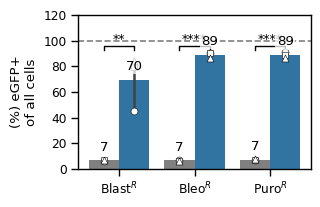

In [61]:
# General plotting params
x = 'cond'
y = 'percent'
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

order = ['vDN194', 'vDN195', 'pKG04440']

antibiotic_map = {
    'vDN194': 'blast',
    'vDN195': 'zeo',
    'pKG04440': 'puro'
}

label_map = {
    'vDN194': 'Blast$^R$',
    'vDN195': 'Bleo$^R$',
    'pKG04440': 'Puro$^R$'
}

# Just get desNb's
df_curr = data_eGFP_percent_reps.loc[
    data_eGFP_percent_reps.cond.isin(order)
].copy()



# ---------------------------------------------------------
# Split into 0 or max
# ---------------------------------------------------------

# Blast: 10 dpt
df_curr.loc[
    (df_curr['blast'] == 0) &
    (df_curr['cond'] == 'vDN194') &
    (df_curr['dpt'] == 10),
    'anti_cat'
] = '0'

df_curr.loc[
    (df_curr['blast'] == 20) &
    (df_curr['cond'] == 'vDN194') &
    (df_curr['dpt'] == 10),
    'anti_cat'
] = 'Max'


# Zeo: 10 dpt
df_curr.loc[
    (df_curr['zeo'] == 0) &
    (df_curr['cond'] == 'vDN195') &
    (df_curr['dpt'] == 10),
    'anti_cat'
] = '0'

df_curr.loc[
    (df_curr['zeo'] == 1000) &
    (df_curr['cond'] == 'vDN195') &
    (df_curr['dpt'] == 10),
    'anti_cat'
] = 'Max'


# Puro
df_curr.loc[
    (df_curr['puro'] == 0) &
    (df_curr['cond'] == 'pKG04440'),
    'anti_cat'
] = '0'

df_curr.loc[
    (df_curr['puro'] == 40) &
    (df_curr['cond'] == 'pKG04440'),
    'anti_cat'
] = 'Max'


hue = 'anti_cat'
hue_order = ['0', 'Max']

palette = {
    '0': 'grey',
    'Max': 'tab:blue'
}


# ---------------------------------------------------------
# Calculate biological replicate means
# ---------------------------------------------------------

bio_means = (
    df_curr
    .dropna(subset=['anti_cat'])
    .groupby(['cond', 'anti_cat', 'rep'], as_index=False)[y]
    .mean()
)


# ---------------------------------------------------------
# Student's two-sided independent t-tests
# ---------------------------------------------------------

from scipy.stats import ttest_ind

p_values = {}

for cond in order:

    zero = bio_means[
        (bio_means['cond'] == cond) &
        (bio_means['anti_cat'] == '0')
    ][y]

    max_val = bio_means[
        (bio_means['cond'] == cond) &
        (bio_means['anti_cat'] == 'Max')
    ][y]

    t_stat, p_val = ttest_ind(
        zero,
        max_val,
        equal_var=True,
        alternative='two-sided'
    )

    p_values[cond] = p_val

    print(
        f"{label_map[cond]}: "
        f"t = {t_stat:.3f}, "
        f"p = {p_val:.4g}"
    )


# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

fig, ax = plt.subplots(1, 1, figsize=(3, 2))

sns.barplot(
    ax=ax,
    data=bio_means,
    x=x,
    y=y,
    hue=hue,
    order=order,
    hue_order=hue_order,
    palette=palette,
    alpha=1
)


# ---------------------------------------------------------
# Plot technical replicates
# ---------------------------------------------------------

for (j, rep) in enumerate(df_curr.rep.dropna().unique()):

    sns.stripplot(
        ax=ax,
        data=bio_means[bio_means.rep == rep],
        x=x,
        y=y,
        hue=hue,
        order=order,
        hue_order=hue_order,
        dodge=True,
        marker=marker_list[j],
        palette={hue: 'white' for hue in hue_order},
        size=5,
        edgecolor='black',
        linewidth=0.4
    )


# Barplot with hue='anti_cat' and dodge=True
# gives the two bars positions around each x tick.
bar_width = 0.8
hue_offset = bar_width / 4

# Put each bracket above the corresponding pair
bracket_y = [93, 93, 93]

for i, cond in enumerate(order):

    x_center = i

    zero_x = x_center - hue_offset
    max_x = x_center + hue_offset

    add_sig_bracket(
        ax,
        zero_x,
        max_x,
        y=bracket_y[i],
        h=3,
        p=p_values[cond]
    )


# ---------------------------------------------------------
# Formatting
# ---------------------------------------------------------

ax.yaxis.set_label_text('(%) eGFP+\nof all cells')
ax.set_ylim((0, 120))

ax.axhline(
    100,
    0,
    1,
    color='grey',
    linestyle='--'
)

ax.set_xlabel('')

ax.set_xticklabels(
    label_map[l] for l in order
)


# Remove existing legend
if ax.get_legend() is not None:
    ax.get_legend().remove()


# Add barplot labels
for sub_ax in plt.gcf().get_axes():
    for i in sub_ax.containers:

        bar_labels = sub_ax.bar_label(
            i,
            fmt='%0.0f',
            padding=5
        )

        for label in bar_labels:
            label.set_bbox(
                dict(
                    facecolor='white',
                    alpha=0.75,
                    linewidth=0,
                    pad=1
                )
            )


plottitle = 'Figure_1E_antibiotic_markers.svg'

plt.savefig(
    rd.outfile(output_path/plottitle),
    bbox_inches='tight'
)

print(df_curr['rep'].unique())